# Paper Figures

In [79]:
import os
import matplotlib.pyplot as plt
from matplotlib import colormaps
from src.models.NSI import NSI
from src.models.channel import *
from src.models.continuous_models import *
from tqdm.notebook import tqdm
import pickle
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import stats
from scipy.interpolate import interp1d
from collections import defaultdict
import numpy as np
import numpy.typing as npt
import networkx as nx
import matplotlib
import seaborn as sns
from collections.abc import Callable
from scipy.optimize import minimize, curve_fit
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Constants

In [2]:
COLORS = ['crimson', 'steelblue', 'goldenrod', 'mediumseagreen']

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"] # Ensures the main text matches the math font
})

## Functions

In [4]:
def simulate(num_runs: int,
             channel: np.ndarray,
             N: int,
             initial_state: np.ndarray,
             beta: float, 
             k: int,
             max_time: int
            ):

    """
    runs: Number of runs 
    channel: Q as a numpy array
    N: population size 
    initial_state: initial INTEGER NUMBER of people with each message at time T=0
    beta: transmissibility 
    k: average number of contacts
    max_time: max simulation time 
    """
        
    alphabet_size = channel.shape[0]

    # Noisy Gillespie Algorithm
    runs = list()
    for _ in tqdm(range(num_runs)):
        
        sim = NoisyGillespie(N=N, initial_state=initial_state, beta=beta, k=k, 
                            channel=channel)
        sim_output = sim.simulate(max_time=max_time, density=True)
        runs.append((sim_output[0], sim_output[1]))
                                 
    # Interpolating Gillespie Means
    common_time = np.linspace(0, max_time, max_time+1)
    interpolated_values = []
    
    for run_t, run_y in runs:
        interp_func = interp1d(run_t, run_y, kind='linear', fill_value='extrapolate', axis=0) 
        interpolated_values.append(interp_func(common_time))
    
    interp_sim_arr = np.array(interpolated_values)

    sim_means = np.mean(interp_sim_arr, axis=0)
    sim_se = np.std(interp_sim_arr, axis=0) / np.sqrt(num_runs)
    conf_int = 1.96 * sim_se

    sim_lower = sim_means - conf_int
    sim_higher = sim_means + conf_int

    sim_lower = np.clip(sim_lower, 0, 1)
    sim_higher = np.clip(sim_higher, 0, 1)

    mean_gillespie_results = (common_time, sim_means)
    gillespie_ci = (sim_lower, sim_higher)

    return mean_gillespie_results, gillespie_ci

In [5]:
def well_mixed_mean_field(channel: np.ndarray,
                          N: int,
                          initial_state: np.ndarray,
                          beta: float, 
                          k: int,
                          max_time: int,
                          common_time: np.ndarray
                         ):

    """
    runs: Number of runs 
    channel: Q as a numpy array
    N: population size 
    initial_state: initial DENSITY of people with each message at time T=0
    beta: transmissibility 
    k: average number of contacts
    max_time: max simulation time 
    common_time: output[0][0] from simulate() or any other range of values to draw points 
    """
    
    mean_field = ODE(beta=beta, k=k, channel=channel, T=max_time, t_eval=common_time)
    analytic_curve = mean_field(initial_state=initial_state)
    mean_field_results = (analytic_curve.t, analytic_curve.y.T)
    return mean_field_results

In [6]:
def plot_simulation(sim_output,
                    alpha: float = 0.3, 
                    colors: list = COLORS,
                    mean_field: None | tuple = None
                   ):

    results, cis = sim_output
    common_time, x = results
    sim_lower, sim_higher = cis
    for dim in range(x.shape[1]):
        plt.plot(common_time, x[:, dim], color=colors[dim])
        plt.fill_between(common_time, x[:, dim], sim_lower[:, dim], 
                                                 alpha=0.6, color=colors[dim])
        plt.fill_between(common_time, x[:, dim], sim_higher[:, dim], 
                                                 alpha=0.6, color=colors[dim])
        if mean_field is not None:
            plt.plot(mean_field[0], mean_field[1], linestyle='dotted', alpha=0.6, 
                                            color='black', markersize=4)

In [7]:
test = simulate(num_runs=10, 
                channel=single_flip_channel(1, 0.1), 
                N=100,
                initial_state=np.array([1, 0]),
                beta=0.05,
                k=4,
                max_time=100
               )

  0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
test_mf = well_mixed_mean_field(channel=single_flip_channel(1, 0.1), 
                                N=100,
                                initial_state=np.array([1/100, 0]),
                                beta=0.05,
                                k=4,
                                max_time=100, 
                                common_time=test[0][0]
                               )

In [ ]:
plot_simulation(test)

## Figure 1: Single-Error Time Dynamics
Binary symmetric channel at a single error value.
Solid lines = simulation mean ± 95% CI (shaded); dashed lines = mean field.

In [ ]:
epsilon = 0.1
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric
num_runs = 1000 
N = 10000
initial_state = np.array([10, 0])
beta = 0.05
k = 4
max_time = 80


binsym01_sim = simulate(num_runs=num_runs,
                        channel=channel,
                        N=N,
                        initial_state=initial_state,
                        beta=beta,
                        k=k,
                        max_time=max_time
                       )

binsym01_mf = well_mixed_mean_field(channel=channel,
                                    N=N,
                                    initial_state=initial_state/N,
                                    beta=beta,
                                    k=k,
                                    max_time=max_time,
                                    common_time=binsym01_sim[0][0]
                                   )

/tmp/ipykernel_1008370/2504513724.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=2, fontsize=8)


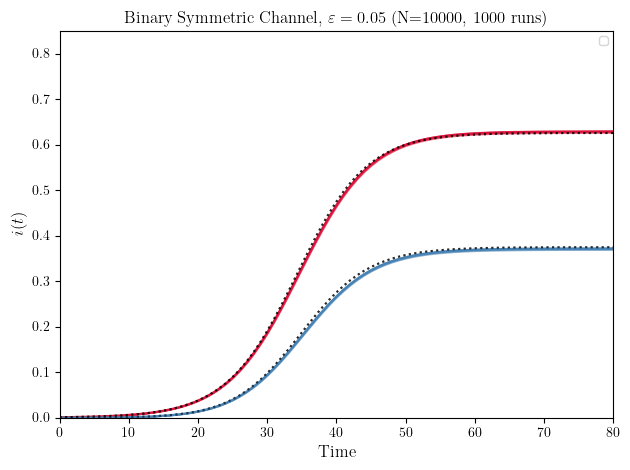

In [16]:
plot_simulation(binsym01_sim, mean_field=binsym01_mf)

plt.xlabel('Time', fontsize=12)
plt.ylabel(r'$i(t)$', fontsize=12)
plt.title(fr'Binary Symmetric Channel, $\varepsilon = {epsilon}$  (N={N}, {num_runs} runs)')
plt.ylim(0, .85)
plt.xlim(0, max_time)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('/home/sagar/modeling-info-spread/reports/figures/PRE_figs/well_mixed_fit_01_new.pdf')
plt.show()

In [ ]:
epsilon = 0.05
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric


binsym001_sim = simulate(num_runs=num_runs,
                        channel=channel,
                        N=N,
                        initial_state=initial_state,
                        beta=beta,
                        k=k,
                        max_time=max_time
                       )

binsym001_mf = well_mixed_mean_field(channel=channel,
                                    N=N,
                                    initial_state=initial_state/N,
                                    beta=beta,
                                    k=k,
                                    max_time=max_time,
                                    common_time=binsym01_sim[0][0]
                                   )

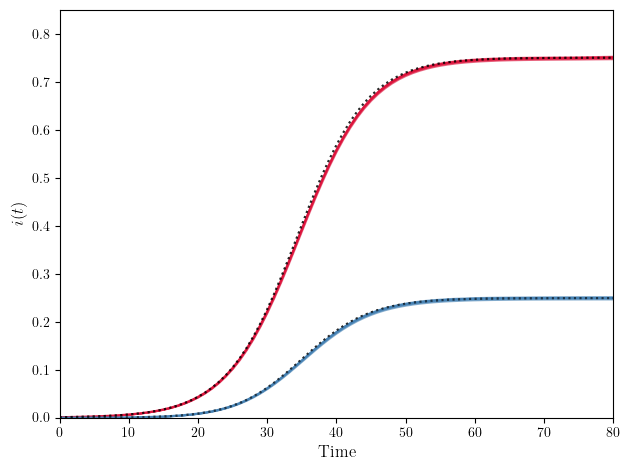

In [17]:
plot_simulation(binsym001_sim, mean_field=binsym001_mf)

plt.xlabel('Time', fontsize=12)
plt.ylabel(r'$i(t)$', fontsize=12)
#plt.title(fr'Binary Symmetric Channel, $\epsilon = {epsilon}$  (N={N}, {num_runs} runs)')
plt.ylim(0, .85)
plt.xlim(0, max_time)
#plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
#plt.savefig('/home/sagar/modeling-info-spread/reports/figures/PRE_figs/well_mixed_fit_001_new.pdf')
plt.show()

## Figure 2: Trajectory with varying $i_0$

In [18]:
## Figure 2: fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
colormap = plt.cm.plasma

# --- Fixed parameters ---
epsilon = 0.1
channel = single_flip_channel(1, epsilon)     # 2x2 binary symmetric, lambda_2 = 1 - 2*epsilon = 0.8
num_runs = 1000
N = 10000
beta = 0.05
k = 4
max_time = 200                                 # longer than before -- small i0 means slower spread

# --- Sweep: total initial infected, log-spaced ---
# With lambda_2 = 0.8, exponent (1 - lambda_2) = 0.2, so i0^0.2 only gets small
# when i0 is very small. Sweep over several decades.
i0_values = np.logspace(-4, -0.3, 10)          # from 10^-4 (=1e-4) up to ~0.5
                                                # in fraction units
# Fixed initial composition: all mass in strain 1
x_tilde_0 = np.array([1.0, 0.0])

# --- Stationary distribution of Q (for plotting pi) ---
# For the symmetric binary channel, pi = (0.5, 0.5).
# In general: compute as the right eigenvector of Q with eigenvalue 1, normalized to sum to 1.
eigvals, eigvecs = np.linalg.eig(channel)
idx = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, idx])
pi = pi / pi.sum()

# Sub-leading eigenvalue (take the one furthest from 1)
lambda_2 = np.real(sorted(eigvals, key=lambda z: -abs(z - 1))[0])

# ============================================================
# Panel 1: trajectories in (i1, i2) plane
# ============================================================
ax = axs[0]

# Simplex boundary (heavy) and symmetry line (light)
ax.plot(np.linspace(0, 1, 100), 1 - np.linspace(0, 1, 100), 'k')
ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), 'grey', alpha=0.4, linewidth=0.7)

# Mark pi on the simplex
#ax.plot(pi[0], pi[1], marker='*', color='red', markersize=14,
#        markeredgecolor='black', zorder=5, label=r'$\boldsymbol{\pi}$')

endpoints_sim = []
endpoints_mf = []

for j, i0 in enumerate(i0_values):
    # Seed: all in strain 1, total fraction = i0
    initial_state = N * i0 * x_tilde_0          # absolute counts for simulate()

    i0_sim = simulate(num_runs=num_runs,
                      channel=channel,
                      N=N,
                      initial_state=initial_state,
                      beta=beta,
                      k=k,
                      max_time=max_time)

    i0_mf = well_mixed_mean_field(channel=channel,
                                  N=N,
                                  initial_state=initial_state / N,
                                  beta=beta,
                                  k=k,
                                  max_time=max_time,
                                  common_time=i0_sim[0][0])

    color = colormap(j / (len(i0_values) - 1))
    ax.plot(i0_mf[1][:, 0],    i0_mf[1][:, 1],    linestyle='dotted', color=color)
    ax.plot(i0_sim[0][1][:, 0], i0_sim[0][1][:, 1], color=color, linewidth=0.7)

    # Store endpoints for panel 2
    endpoints_sim.append(i0_sim[0][1][-1])
    endpoints_mf.append(i0_mf[1][-1])

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r'$i_1(t)$')
ax.set_ylabel(r'$i_2(t)$')
#ax.legend(loc='upper right')

# Colorbar: log-spaced i0
normalize = mcolors.LogNorm(vmin=i0_values.min(), vmax=i0_values.max())
sm = plt.cm.ScalarMappable(norm=normalize, cmap=colormap)
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'Initial infected fraction $i_0$')

# ============================================================
# Panel 2: |x(inf) - pi| vs i0, log-log, with predicted slope
# ============================================================
ax = axs[1]

endpoints_sim = np.array(endpoints_sim)
endpoints_mf  = np.array(endpoints_mf)

dist_sim = np.linalg.norm(endpoints_sim - pi, axis=1)
dist_mf  = np.linalg.norm(endpoints_mf  - pi, axis=1)

ax.loglog(i0_values, dist_sim, 'o', label='simulation', color='C0')
ax.loglog(i0_values, dist_mf,  's', label='mean field', color='C1', markerfacecolor='none')

# Theory line: |x(inf) - pi| = |v2 . x_tilde_0| * ||u2|| * i0^(1 - lambda_2)
# For the symmetric 2-strain case with x_tilde_0 = (1,0):
#   v2 = (0.5, -0.5), u2 = (1, -1), so |v2 . x_tilde_0| * ||u2|| = 0.5 * sqrt(2)
# More generally, fit or compute from the decomposition of Q.
prefactor = 0.5 * np.sqrt(2)
theory = prefactor * i0_values ** (1 - lambda_2)
ax.loglog(i0_values, theory, 'k--',
          label=rf'theory: $i_0^{{1-\lambda_2}}$, $\lambda_2={lambda_2:.2f}$')

ax.set_xlabel(r'$i_0$')
ax.set_ylabel(r'$\|\mathbf{x}(\infty) - \boldsymbol{\pi}\|$')
ax.legend()

plt.tight_layout()
plt.savefig("/home/sagar/modeling-info-spread/reports/figures/PRE_figs/convergence_figs_new.pdf")
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Figure 2.5: Mean-field accuracy with no. of runs (Well-Mixed, Insert)

In [ ]:
#model_errs = []

epsilon = 0.05
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric 
N = 10000
beta = 0.05
k = 4
max_time = 80
initial_state = np.array([10, 0]) 


for n in np.logspace(0, 5, num=6):

    
    # TODO: simulation loop
    sim = simulate(num_runs=int(n),
                   channel=channel,
                   N=N,
                   initial_state=initial_state,
                   beta=beta,
                   k=k,
                   max_time=max_time
                  )
    
    mean_field = well_mixed_mean_field(channel=channel,
                                       N=N,
                                       initial_state=i0_initial_state/N,
                                       beta=beta,
                                       k=k,
                                       max_time=max_time,
                                       common_time=sim[0][0]
                                      )
    # TODO: RMSE
    rmse = np.sqrt(np.mean((sim[0][1][:,0] - mean_field[1][:,0])**2))

    model_errs.append(rmse)

In [ ]:
#np.savez('errors_by_runs.npz', model_errs)

In [ ]:
plt.loglog(np.logspace(0, 5, num=6), model_errs, 'o')

## Figure 3: Dynamics Varying Q

In [19]:
def spectral_data(Q):
    """Return pi (stationary distribution) and sub-leading eigenvalues
    sorted by descending |lambda - 1| relevance, plus eigenvectors."""
    eigvals, eigvecs_R = np.linalg.eig(Q)
    # Stationary: eigenvalue closest to 1
    idx1 = np.argmin(np.abs(eigvals - 1))
    pi = np.real(eigvecs_R[:, idx1])
    pi = pi / pi.sum()
    # Sub-leading: largest |lambda| among the rest
    rest = [i for i in range(len(eigvals)) if i != idx1]
    rest_sorted = sorted(rest, key=lambda i: -np.abs(eigvals[i]))
    lambdas_sub = np.array([eigvals[i] for i in rest_sorted])
    return pi, lambdas_sub, eigvals, eigvecs_R


def two_strain_Q(eps1, eps2):
    """Asymmetric 2-strain channel:
       Q = [[1-eps1, eps2], [eps1, 1-eps2]]
    Column-stochastic. Symmetric BSC is the eps1=eps2 diagonal."""
    return np.array([[1 - eps1, eps2],
                     [eps1,     1 - eps2]])

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

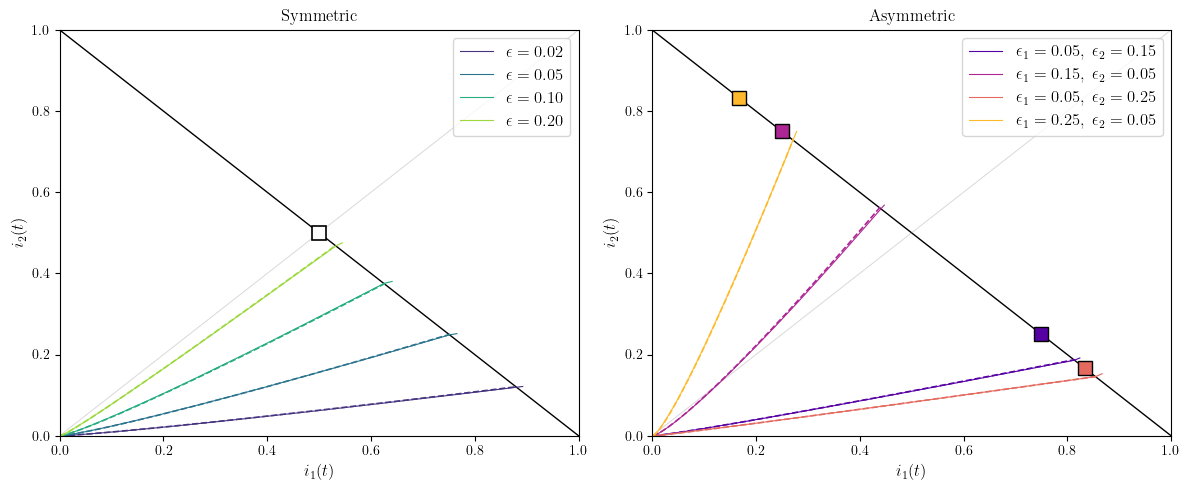

In [20]:
# Fixed dynamical parameters
num_runs = 1000
N = 10000
beta = 0.05
k = 4
max_time = 200
i0 = 1e-3
initial_state = np.array([N * i0, 0])

# Symmetric cases (eps1 = eps2)
sym_cases = [
    (0.02, 0.02, r'$\epsilon = 0.02$'),
    (0.05, 0.05, r'$\epsilon = 0.05$'),
    (0.10, 0.10, r'$\epsilon = 0.10$'),
    (0.20, 0.20, r'$\epsilon = 0.20$'),
]
sym_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(sym_cases)))

# Asymmetric cases
asym_cases = [
    (0.05, 0.15, r'$\epsilon_1=0.05,\ \epsilon_2=0.15$'),
    (0.15, 0.05, r'$\epsilon_1=0.15,\ \epsilon_2=0.05$'),
    (0.05, 0.25, r'$\epsilon_1=0.05,\ \epsilon_2=0.25$'),
    (0.25, 0.05, r'$\epsilon_1=0.25,\ \epsilon_2=0.05$'),
]
asym_colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(asym_cases)))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def plot_simplex_frame(ax):
    ax.plot(np.linspace(0, 1, 100), 1 - np.linspace(0, 1, 100),
            'k', lw=1)
    ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100),
            'grey', alpha=0.3, lw=0.7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(r'$i_1(t)$', fontsize=12)
    ax.set_ylabel(r'$i_2(t)$',fontsize=12)

def run_and_plot(ax, eps1, eps2, color, label):
    Q = two_strain_Q(eps1, eps2)
    sim = simulate(num_runs=num_runs, channel=Q, N=N,
                   initial_state=initial_state, beta=beta,
                   k=k, max_time=max_time)
    mf = well_mixed_mean_field(channel=Q, N=N,
                               initial_state=initial_state / N,
                               beta=beta, k=k, max_time=max_time,
                               common_time=sim[0][0])
    ax.plot(mf[1][:, 0], mf[1][:, 1], '--', color=color, lw=1.2)
    ax.plot(sim[0][1][:, 0], sim[0][1][:, 1], color=color,
            lw=0.8, label=label)

# ---------- Left panel: symmetric ----------
ax = axs[0]
plot_simplex_frame(ax)
for (eps1, eps2, label), color in zip(sym_cases, sym_colors):
    run_and_plot(ax, eps1, eps2, color, label)
# Single white star at pi = (0.5, 0.5)
ax.plot(0.5, 0.5, marker='s', color='white', markersize=10,
        markeredgecolor='black', markeredgewidth=1.2, zorder=10)
ax.legend(fontsize=12, loc='upper right')
ax.set_title(r'Symmetric')

# ---------- Right panel: asymmetric ----------
ax = axs[1]
plot_simplex_frame(ax)
for (eps1, eps2, label), color in zip(asym_cases, asym_colors):
    run_and_plot(ax, eps1, eps2, color, label)
    # Plot colored star at theoretical pi
    pi_theory = np.array([eps2, eps1]) / (eps1 + eps2)
    ax.plot(pi_theory[0], pi_theory[1], marker='s', color=color,
            markersize=10, markeredgecolor='black',
            markeredgewidth=1.0, zorder=10)
ax.legend(fontsize=12, loc='upper right')
ax.set_title(r'Asymmetric')

plt.tight_layout()
#plt.savefig("/home/sagar/modeling-info-spread/reports/figures/PRE_figs/varying_Q_FULL.pdf")

## Figure 4: Mean Field on Network

In [ ]:
from src.models.continuous_graph_model import *

In [66]:
epsilon = 0.05

N = 10000
k = 4
beta = 0.05
y0 = np.array([1, 0, k * (N-1)/N, 0, k*(N-1)**2 / N])
t = 200
t_span = (0, t)
t_eval = np.linspace(0, t, 100)
Q = single_flip_channel(1, epsilon) 
r = Q * beta

In [ ]:
reg_runs = []

regG = nx.random_regular_graph(k, N)
for run in tqdm(range(1000)): #1000
    initial_infected = {np.random.randint(N): 0}
    sim = NetworkGillespie(G=regG, initial_infected=initial_infected, beta=beta, channel=Q)
    run = sim.simulate(max_time=t, density=False)
    reg_runs.append(run)

 20%|██████▊                            | 196/1000 [3:04:12<12:40:23, 56.75s/it]

Text(0.5, 1.0, 'Dynamics on k-Regular Graph')

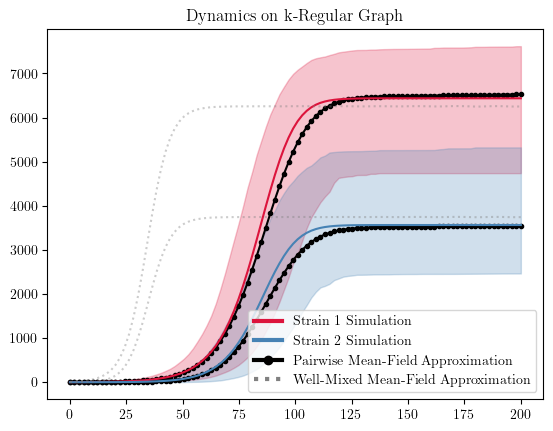

In [82]:
interpolated_curves_reg = []
for run_t, run_y in reg_runs:
    interp_func = interp1d(run_t, run_y, kind='linear', fill_value='extrapolate', axis=0)
    interpolated_curves_reg.append(interp_func(t_eval))


Y_reg = np.array(interpolated_curves_reg)
mean_curves = np.mean(Y_reg, axis=0)
low_reg, high_reg = np.nanpercentile(Y_reg, [5, 95], axis=0)

sol_pairwise = solve_ivp(two_state_pairwise, t_span, y0, args=(N,k,r), t_eval=t_eval, method='RK45')

plt.plot(t_eval, mean_curves, color='k', linestyle=None, marker='.')
plt.plot(sol_pairwise.t, sol_pairwise.y.T[:,0], linestyle='solid', color=COLORS[0])
plt.plot(sol_pairwise.t, sol_pairwise.y.T[:,1], linestyle='solid', color=COLORS[1])
plt.fill_between(t_eval, low_reg[:,0], high_reg[:,0], alpha=0.25, color=COLORS[0])
plt.fill_between(t_eval, low_reg[:,1], high_reg[:,1], alpha=0.25, color=COLORS[1])
#plt.xlim(0, 170)

# Well-mixed mean field as dotted lines

pairwise_comparision_mf = well_mixed_mean_field(channel=channel,
                                    N=N,
                                    initial_state=initial_state/N,
                                    beta=beta,
                                    k=k,
                                    max_time=max_time,
                                    common_time=t_eval
                                   )

plt.plot(pairwise_comparision_mf[0], pairwise_comparision_mf[1]*N, linestyle='dotted', alpha=0.4, 
                                            color='grey', markersize=4)

legend_elements = [
    # Custom solid line entry
    Line2D([0], [0], color=COLORS[0], lw=3, linestyle='-', label='Strain 1 Simulation'),
    Line2D([0], [0], color=COLORS[1], lw=3, linestyle='-', label='Strain 2 Simulation'),
    Line2D([0], [0], color='k', lw=3, marker='o', label='Pairwise Mean-Field Approximation'),
    Line2D([0], [0], color='grey', lw=3, linestyle='dotted', label='Well-Mixed Mean-Field Approximation'),
]

plt.legend(handles=legend_elements, loc='lower right')
plt.title('Dynamics on k-Regular Graph')
#plt.savefig("/home/sagar/modeling-info-spread/reports/figures/PRE_figs/regular_graph_fit_FINAL_shorter.pdf")

/home/sagar/modeling-info-spread/src/models/continuous_graph_model.py:341: RuntimeWarning: divide by zero encountered in scalar divide
  dsi1 = ((k-1)*ss/(k*s))*(r[0,0]*si1 + r[0,1]*si2) - r[0,0]*si1 - r[1,0]*si1 - \
/home/sagar/modeling-info-spread/src/models/continuous_graph_model.py:342: RuntimeWarning: divide by zero encountered in scalar divide
  ((k-1)/(k*s))*(r[0,0]*si1**2 + r[1,0]*si1**2 + r[0,1]*si1*si2 + r[1,1]*si1*si2)
/home/sagar/modeling-info-spread/src/models/continuous_graph_model.py:343: RuntimeWarning: divide by zero encountered in scalar divide
  dsi2 = ((k-1)*ss/(k*s))*(r[1,0]*si1 + r[1,1]*si2) - r[0,1]*si2 - r[1,1]*si2 - \
/home/sagar/modeling-info-spread/src/models/continuous_graph_model.py:344: RuntimeWarning: divide by zero encountered in scalar divide
  ((k-1)/(k*s))*(r[0,1]*si2**2 + r[1,1]*si2**2 + r[1,0]*si1*si2 + r[0,0]*si1*si2)
/home/sagar/modeling-info-spread/src/models/continuous_graph_model.py:345: RuntimeWarning: divide by zero encountered in scalar divi

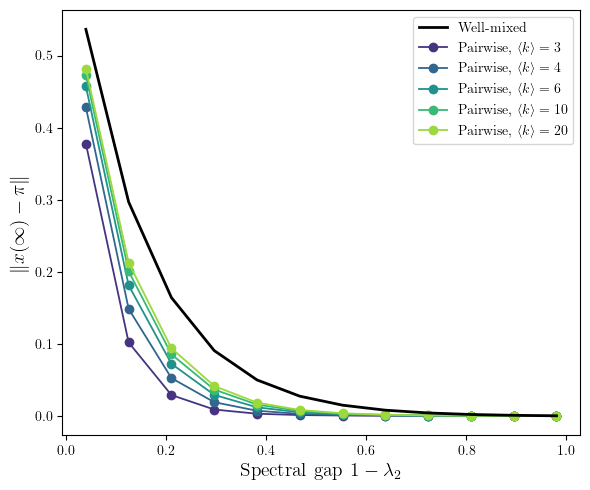

In [63]:
# ============================================================
# Setup
# ============================================================
N = 10000           # only enters as a scale in pairwise IC; doesn't affect ratio
beta = 0.05
i0_frac = 0.001     # fraction of population initially infected
max_time = 1000     # long enough for both to plateau at any reasonable spectral gap
t_eval = np.linspace(0, max_time, 500)

def well_mixed_endpoint(Q, beta, k, i0_frac, max_time, t_eval, N):
    """Integrate the well-mixed MF and return x(infinity)."""
    initial_state = np.array([N * i0_frac, 0]) / N   # fraction
    mf = well_mixed_mean_field(channel=Q, N=N,
                               initial_state=np.array([N*i0_frac, 0]) / N,
                               beta=beta, k=k, max_time=max_time,
                               common_time=t_eval)
    return mf[1][-1]   # last row of trajectory, in fractions

def pairwise_endpoint(Q, beta, k, i0_frac, max_time, t_eval, N):
    """Integrate the pairwise MF on a k-regular graph and return x(infinity)."""
    r = Q * beta
    i0_count = N * i0_frac
    y0 = np.array([i0_count, 0,
                   k * (N - i0_count) / N, 0,
                   k * (N - i0_count)**2 / N])
    sol = solve_ivp(two_state_pairwise, (0, max_time), y0,
                    args=(N, k, r), t_eval=t_eval, method='RK45',
                    rtol=1e-9, atol=1e-12)
    return sol.y.T[-1, :2] / N   # first two components, as fractions

# ============================================================
# Sweep over (eps, k)
# ============================================================
epsilon_values = np.linspace(0.02, 0.49, 12)
k_values = [3, 4, 6, 10, 20]

results = {}   # (k, eps) -> (wm_dev, pw_dev)

for k in k_values:
    for eps in epsilon_values:
        Q = single_flip_channel(1, eps)
        pi, _, _, _ = spectral_data(Q)

        x_wm = well_mixed_endpoint(Q, beta, k, i0_frac, max_time, t_eval, N)
        x_pw = pairwise_endpoint(Q, beta, k, i0_frac, max_time, t_eval, N)

        wm_dev = np.linalg.norm(x_wm - pi)
        pw_dev = np.linalg.norm(x_pw - pi)
        results[(k, eps)] = (wm_dev, pw_dev)

# ============================================================
# Plot: deviation from pi vs spectral gap, one curve per k
# ============================================================
fig, axs = plt.subplots(figsize=(6, 5))

# Panel A: raw deviations
ax = axs
spectral_gaps = 2 * epsilon_values   # 1 - lambda_2 for symmetric BSC

# Well-mixed is k-independent — plot once
wm_devs = [results[(k_values[0], eps)][0] for eps in epsilon_values]
ax.plot(spectral_gaps, wm_devs, 'k-', lw=2, label='Well-mixed', zorder=10)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(k_values)))
for k, color in zip(k_values, colors):
    pw_devs = [results[(k, eps)][1] for eps in epsilon_values]
    ax.plot(spectral_gaps, pw_devs, 'o-', color=color, lw=1.3,
            label=fr'Pairwise, $\langle k \rangle = {k}$')

ax.set_xlabel(r'Spectral gap $1 - \lambda_2$', fontsize=14)
ax.set_ylabel(r'$\|x(\infty) - \pi\|$', fontsize=14)
ax.legend(fontsize=10)
#ax.set_title('Deviation from spectral attractor')

plt.tight_layout()
plt.savefig("/home/sagar/modeling-info-spread/reports/figures/PRE_figs/graph_gap_FINAL.pdf")